# Linear and Logistic Regression: Model Choice and Diagnostics

**Context:** Guided regression exercises, consolidated and extended for portfolio presentation  
**Tools:** Python, pandas, scikit-learn, Matplotlib, seaborn  
**Methods:** linear regression, multinomial logistic regression, cross-validation,
residual diagnostics, confusion matrices, probability-bound checks

## TL;DR

- Multinomial logistic regression reaches a mean five-fold macro F1 of **0.958** on the
  Iris training data and **93.3% accuracy** on a 30-observation holdout set.
- Multiple linear regression predicts Iris sepal length with **0.324 cm RMSE** and
  **0.828 R²** on the holdout set, compared with **0.816 cm RMSE** for a training-mean
  baseline.
- Diabetes `Outcome` is binary, so ordinary linear regression is not an appropriate
  probability model. Its holdout predictions include **27 of 192 values outside [0, 1]**.
  Logistic regression keeps every estimated probability within valid bounds and achieves
  **0.824 ROC-AUC** and **0.696 average precision**.
- The Diabetes comparison preserves all **768 rows**. Physiologically implausible zeros are
  treated as missing and median-imputed inside the training pipeline rather than deleting
  rows before the split.

## Context & Methods

The project answers one central question: **how should the target variable determine the
model family and evaluation metrics?**

1. Iris species is categorical, so logistic regression is evaluated with classification
   metrics.
2. Iris sepal length is continuous, so linear regression is evaluated with MAE, RMSE, R²,
   and residuals.
3. Diabetes outcome is binary. Ordinary linear regression is retained only as a diagnostic
   linear-probability baseline; logistic regression is the appropriate model for bounded
   class probabilities.

### Key assumptions

- Train/test splits are deterministic; classification splits are stratified.
- Model comparison uses cross-validation on training data where alternatives are selected.
- Imputation and scaling are learned inside pipelines, never from holdout data.
- Regression coefficients describe conditional associations, not causal effects.
- These small teaching datasets do not establish production or clinical performance.

## Setup

Place `iris.csv` and `diabetes.csv` in this project's `data/` folder. Raw teaching datasets
are excluded from GitHub because redistribution permissions have not been established.

References:

- [MLU Explain: linear regression](https://mlu-explain.github.io/linear-regression/)
- [MLU Explain: logistic regression](https://mlu-explain.github.io/logistic-regression/)
- [scikit-learn: linear models](https://scikit-learn.org/stable/modules/linear_model.html)
- [scikit-learn: regression metrics](https://scikit-learn.org/stable/api/sklearn.metrics.html#regression-metrics)
- [scikit-learn: classification metrics](https://scikit-learn.org/stable/api/sklearn.metrics.html#classification-metrics)

In [1]:
from pathlib import Path
import hashlib
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    recall_score,
    r2_score,
    root_mean_squared_error,
    roc_auc_score,
)
from sklearn.model_selection import (
    KFold,
    StratifiedKFold,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
pd.set_option("display.precision", 4)
sns.set_theme(style="whitegrid", context="notebook")

In [2]:
def locate_data_file(filename, environment_variable):
    environment_path = os.getenv(environment_variable)
    candidates = [
        Path(environment_path) if environment_path else None,
        Path("data") / filename,
        Path("linear-and-logistic-regression/data") / filename,
        Path("../linear-and-logistic-regression/data") / filename,
    ]
    for candidate in candidates:
        if candidate is not None and candidate.exists():
            return candidate
    raise FileNotFoundError(
        f"Could not find {filename!r}. Add it to this project's data/ folder."
    )


iris_path = locate_data_file("iris.csv", "IRIS_DATA_PATH")
diabetes_path = locate_data_file("diabetes.csv", "DIABETES_DATA_PATH")
iris = pd.read_csv(iris_path)
diabetes = pd.read_csv(diabetes_path)

## Data

In [3]:
expected_iris_columns = {
    "Id", "SepalLengthCm", "SepalWidthCm", "PetalLengthCm",
    "PetalWidthCm", "Species"
}
expected_diabetes_columns = {
    "Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin",
    "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"
}
assert set(iris.columns) == expected_iris_columns
assert set(diabetes.columns) == expected_diabetes_columns
assert set(diabetes["Outcome"].unique()) == {0, 1}

data_profile = pd.DataFrame(
    {
        "rows": [len(iris), len(diabetes)],
        "columns": [iris.shape[1], diabetes.shape[1]],
        "missing_cells": [
            int(iris.isna().sum().sum()),
            int(diabetes.isna().sum().sum()),
        ],
        "exact_duplicates": [
            int(iris.duplicated().sum()),
            int(diabetes.duplicated().sum()),
        ],
        "sha256": [
            hashlib.sha256(iris_path.read_bytes()).hexdigest(),
            hashlib.sha256(diabetes_path.read_bytes()).hexdigest(),
        ],
    },
    index=["Iris", "Diabetes"],
)
data_profile

,rows,columns,missing_cells,exact_duplicates,sha256
Iris,150,6,0,0,600ac44f23c2e6e0ae37daac8ceb2baba4df963efa580e...
Diabetes,768,9,0,0,698c203a14aa31941d2251175330c9199f3ccdb31597ab...


## Results

### 1. Iris species classification with logistic regression

In [4]:
iris_feature_columns = [
    "SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"
]
iris_classification_X = iris[iris_feature_columns].copy()
iris_classification_y = iris["Species"].copy()

iris_cls_X_train, iris_cls_X_test, iris_cls_y_train, iris_cls_y_test = (
    train_test_split(
        iris_classification_X,
        iris_classification_y,
        test_size=0.20,
        stratify=iris_classification_y,
        random_state=RANDOM_STATE,
    )
)

iris_classifier = Pipeline(
    [
        ("scaler", StandardScaler()),
        (
            "model",
            LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
        ),
    ]
)
iris_classification_cv = cross_validate(
    iris_classifier,
    iris_cls_X_train,
    iris_cls_y_train,
    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    scoring={"accuracy": "accuracy", "macro_f1": "f1_macro"},
    n_jobs=1,
)

pd.Series(
    {
        "cv_accuracy_mean": iris_classification_cv["test_accuracy"].mean(),
        "cv_accuracy_std": iris_classification_cv["test_accuracy"].std(),
        "cv_macro_f1_mean": iris_classification_cv["test_macro_f1"].mean(),
        "cv_macro_f1_std": iris_classification_cv["test_macro_f1"].std(),
    },
    name="5-fold training CV",
).round(4).to_frame()

,5-fold training CV
cv_accuracy_mean,0.9583
cv_accuracy_std,0.0264
cv_macro_f1_mean,0.9580
cv_macro_f1_std,0.0268


In [5]:
iris_classifier.fit(iris_cls_X_train, iris_cls_y_train)
iris_class_predictions = iris_classifier.predict(iris_cls_X_test)

iris_classification_metrics = pd.Series(
    {
        "accuracy": accuracy_score(iris_cls_y_test, iris_class_predictions),
        "balanced_accuracy": balanced_accuracy_score(
            iris_cls_y_test, iris_class_predictions
        ),
        "macro_f1": f1_score(
            iris_cls_y_test,
            iris_class_predictions,
            average="macro",
            zero_division=0,
        ),
    },
    name="Iris holdout",
)
iris_classification_metrics.round(4).to_frame()

,Iris holdout
accuracy,0.9333
balanced_accuracy,0.9333
macro_f1,0.9333


In [6]:
iris_classification_report = pd.DataFrame(
    classification_report(
        iris_cls_y_test,
        iris_class_predictions,
        output_dict=True,
        zero_division=0,
    )
).T
iris_classification_report.round(3)

,precision,recall,f1-score,support
Iris-setosa,1.000,1.000,1.000,10.000
Iris-versicolor,0.900,0.900,0.900,10.000
Iris-virginica,0.900,0.900,0.900,10.000
accuracy,0.933,0.933,0.933,0.933
macro avg,0.933,0.933,0.933,30.000
weighted avg,0.933,0.933,0.933,30.000


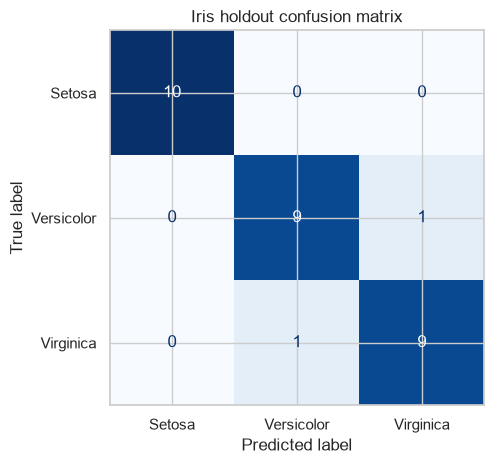

In [7]:
figure, axis = plt.subplots(figsize=(6.4, 4.8))
ConfusionMatrixDisplay.from_predictions(
    iris_cls_y_test,
    iris_class_predictions,
    labels=sorted(iris_classification_y.unique()),
    display_labels=["Setosa", "Versicolor", "Virginica"],
    cmap="Blues",
    colorbar=False,
    ax=axis,
)
axis.set_title("Iris holdout confusion matrix")
plt.tight_layout()
plt.show()

The classifier correctly identifies all Setosa observations and makes two errors between
Versicolor and Virginica. The confusion matrix shows where the 93.3% accuracy comes from;
the balanced holdout design contains ten observations from each species.

### 2. Iris sepal-length prediction with linear regression

In [8]:
iris_regression_features = [
    "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"
]
iris_regression_X = iris[iris_regression_features].copy()
iris_regression_y = iris["SepalLengthCm"].copy()

iris_reg_X_train, iris_reg_X_test, iris_reg_y_train, iris_reg_y_test = (
    train_test_split(
        iris_regression_X,
        iris_regression_y,
        test_size=0.30,
        random_state=12,
    )
)

feature_sets = {
    "Sepal width only": ["SepalWidthCm"],
    "Petal length only": ["PetalLengthCm"],
    "All three measurements": iris_regression_features,
}
regression_cv = KFold(5, shuffle=True, random_state=RANDOM_STATE)
iris_regression_rows = []
for model_name, feature_columns in feature_sets.items():
    scores = cross_validate(
        LinearRegression(),
        iris_reg_X_train[feature_columns],
        iris_reg_y_train,
        cv=regression_cv,
        scoring={
            "mae": "neg_mean_absolute_error",
            "rmse": "neg_root_mean_squared_error",
            "r2": "r2",
        },
        n_jobs=1,
    )
    iris_regression_rows.append(
        {
            "model": model_name,
            "mae_mean": -scores["test_mae"].mean(),
            "rmse_mean": -scores["test_rmse"].mean(),
            "r2_mean": scores["test_r2"].mean(),
        }
    )

iris_regression_cv_results = (
    pd.DataFrame(iris_regression_rows)
    .set_index("model")
    .sort_values("rmse_mean")
)
iris_regression_cv_results.round(4)

,mae_mean,rmse_mean,r2_mean
model,,,
All three measurements,0.2558,0.3123,0.8456
Petal length only,0.3352,0.4038,0.7453
Sepal width only,0.7040,0.8407,-0.0949


In [9]:
selected_iris_regression_name = iris_regression_cv_results.index[0]
selected_iris_features = feature_sets[selected_iris_regression_name]
iris_regressor = LinearRegression().fit(
    iris_reg_X_train[selected_iris_features], iris_reg_y_train
)
iris_regression_predictions = iris_regressor.predict(
    iris_reg_X_test[selected_iris_features]
)
iris_baseline_predictions = np.repeat(
    iris_reg_y_train.mean(), len(iris_reg_y_test)
)

iris_regression_metrics = pd.DataFrame(
    {
        "Selected linear model": {
            "MAE": mean_absolute_error(
                iris_reg_y_test, iris_regression_predictions
            ),
            "RMSE": root_mean_squared_error(
                iris_reg_y_test, iris_regression_predictions
            ),
            "R2": r2_score(iris_reg_y_test, iris_regression_predictions),
        },
        "Training-mean baseline": {
            "MAE": mean_absolute_error(
                iris_reg_y_test, iris_baseline_predictions
            ),
            "RMSE": root_mean_squared_error(
                iris_reg_y_test, iris_baseline_predictions
            ),
            "R2": r2_score(iris_reg_y_test, iris_baseline_predictions),
        },
    }
)
iris_regression_metrics.round(4)

,Selected linear model,Training-mean baseline
MAE,0.2562,0.6866
RMSE,0.3235,0.8155
R2,0.8277,-0.0945


In [10]:
iris_coefficients = pd.Series(
    iris_regressor.coef_,
    index=selected_iris_features,
    name="coefficient_cm_per_cm",
)
print(f"Intercept: {iris_regressor.intercept_:.3f} cm")
iris_coefficients.round(3).to_frame()

Intercept: 1.705 cm


,coefficient_cm_per_cm
SepalWidthCm,0.669
PetalLengthCm,0.771
PetalWidthCm,-0.687


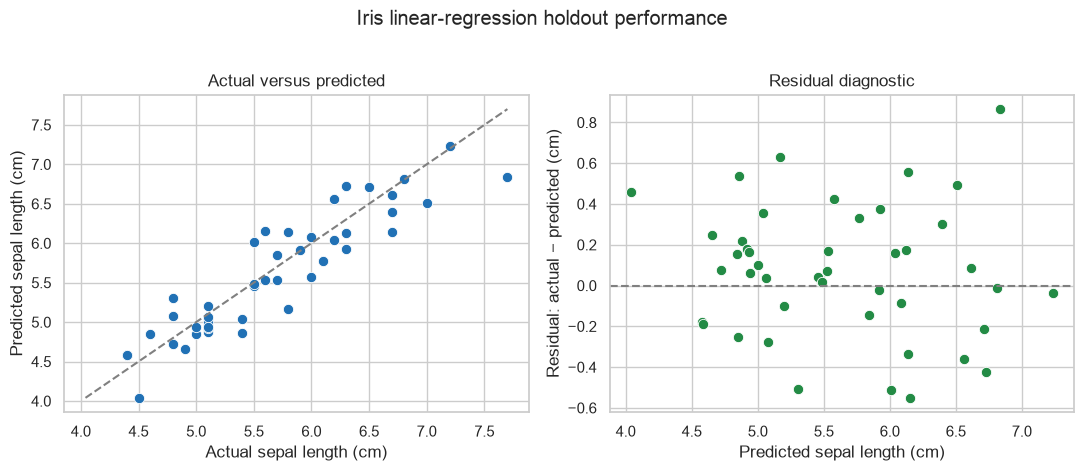

In [11]:
iris_residuals = iris_reg_y_test - iris_regression_predictions
figure, axes = plt.subplots(1, 2, figsize=(11, 4.6))

sns.scatterplot(
    x=iris_reg_y_test,
    y=iris_regression_predictions,
    color="#2171b5",
    s=55,
    ax=axes[0],
)
bounds = [
    min(iris_reg_y_test.min(), iris_regression_predictions.min()),
    max(iris_reg_y_test.max(), iris_regression_predictions.max()),
]
axes[0].plot(bounds, bounds, linestyle="--", color="grey")
axes[0].set_xlabel("Actual sepal length (cm)")
axes[0].set_ylabel("Predicted sepal length (cm)")
axes[0].set_title("Actual versus predicted")

sns.scatterplot(
    x=iris_regression_predictions,
    y=iris_residuals,
    color="#238b45",
    s=55,
    ax=axes[1],
)
axes[1].axhline(0, linestyle="--", color="grey")
axes[1].set_xlabel("Predicted sepal length (cm)")
axes[1].set_ylabel("Residual: actual − predicted (cm)")
axes[1].set_title("Residual diagnostic")

figure.suptitle("Iris linear-regression holdout performance", y=1.02)
plt.tight_layout()
plt.show()

Cross-validation selects all three available measurements. The holdout RMSE is 0.324 cm,
substantially below the 0.816 cm training-mean baseline. Petal length and petal width are
strongly related, so individual coefficient signs should not be interpreted in isolation or
as causal effects.

### 3. Diabetes: why binary outcomes need logistic regression

In [12]:
diabetes_X = diabetes.drop(columns="Outcome").copy()
diabetes_y = diabetes["Outcome"].copy()
zero_as_missing_columns = [
    "Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"
]
zero_counts = diabetes_X[zero_as_missing_columns].eq(0).sum().rename(
    "zero_placeholders"
)
diabetes_X[zero_as_missing_columns] = diabetes_X[
    zero_as_missing_columns
].replace(0, np.nan)

zero_counts.to_frame()

,zero_placeholders
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11


In [13]:
diabetes_X_train, diabetes_X_test, diabetes_y_train, diabetes_y_test = (
    train_test_split(
        diabetes_X,
        diabetes_y,
        test_size=0.25,
        stratify=diabetes_y,
        random_state=RANDOM_STATE,
    )
)

def diabetes_pipeline(estimator):
    return Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", estimator),
        ]
    )


linear_probability_model = diabetes_pipeline(LinearRegression()).fit(
    diabetes_X_train, diabetes_y_train
)
logistic_diabetes_model = diabetes_pipeline(
    LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
).fit(diabetes_X_train, diabetes_y_train)

linear_probability_scores = linear_probability_model.predict(diabetes_X_test)
logistic_probability_scores = logistic_diabetes_model.predict_proba(
    diabetes_X_test
)[:, 1]

In [14]:
probability_range_comparison = pd.DataFrame(
    {
        "minimum_prediction": [
            linear_probability_scores.min(),
            logistic_probability_scores.min(),
        ],
        "maximum_prediction": [
            linear_probability_scores.max(),
            logistic_probability_scores.max(),
        ],
        "outside_0_1": [
            int(
                ((linear_probability_scores < 0) | (linear_probability_scores > 1)).sum()
            ),
            int(
                ((logistic_probability_scores < 0) | (logistic_probability_scores > 1)).sum()
            ),
        ],
    },
    index=["Linear probability model", "Logistic regression"],
)
probability_range_comparison.round(4)

,minimum_prediction,maximum_prediction,outside_0_1
Linear probability model,-0.2820,1.2459,27
Logistic regression,0.0094,0.9910,0


In [15]:
def binary_metric_row(y_true, scores):
    predictions = (scores >= 0.50).astype(int)
    return {
        "accuracy": accuracy_score(y_true, predictions),
        "balanced_accuracy": balanced_accuracy_score(y_true, predictions),
        "precision": precision_score(y_true, predictions),
        "recall": recall_score(y_true, predictions),
        "f1": f1_score(y_true, predictions),
        "roc_auc": roc_auc_score(y_true, scores),
        "average_precision": average_precision_score(y_true, scores),
        "mean_squared_error": mean_squared_error(y_true, scores),
    }


diabetes_model_metrics = pd.DataFrame(
    {
        "Linear probability model": binary_metric_row(
            diabetes_y_test, linear_probability_scores
        ),
        "Logistic regression": binary_metric_row(
            diabetes_y_test, logistic_probability_scores
        ),
    }
).T
diabetes_model_metrics.round(4)

,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,average_precision,mean_squared_error
Linear probability model,0.7292,0.6777,0.6415,0.5075,0.5667,0.8227,0.693,0.1668
Logistic regression,0.7240,0.6737,0.6296,0.5075,0.5620,0.8239,0.696,0.1699


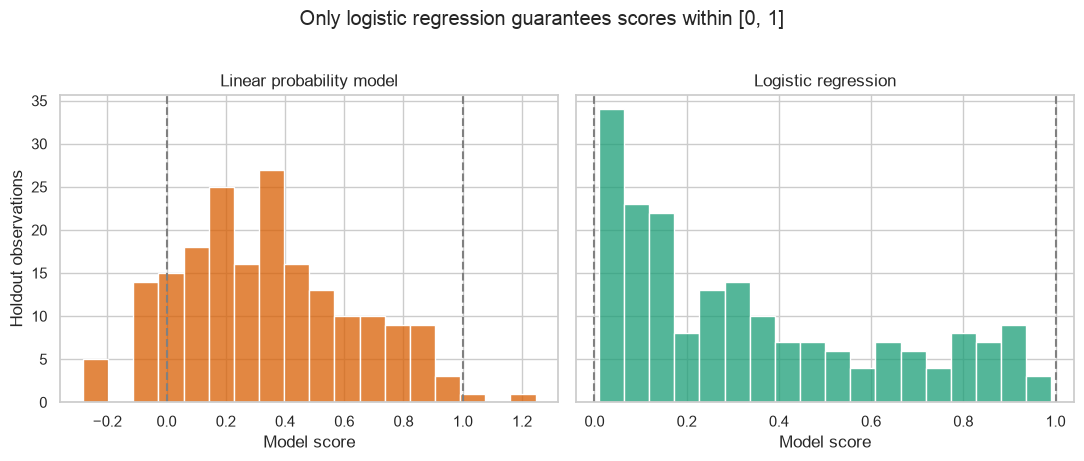

In [16]:
figure, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
for axis, scores, title, color in [
    (
        axes[0],
        linear_probability_scores,
        "Linear probability model",
        "#d95f02",
    ),
    (
        axes[1],
        logistic_probability_scores,
        "Logistic regression",
        "#1b9e77",
    ),
]:
    sns.histplot(scores, bins=18, color=color, alpha=0.75, ax=axis)
    axis.axvline(0, linestyle="--", color="grey")
    axis.axvline(1, linestyle="--", color="grey")
    axis.set_xlabel("Model score")
    axis.set_title(title)
axes[0].set_ylabel("Holdout observations")
figure.suptitle("Only logistic regression guarantees scores within [0, 1]", y=1.02)
plt.tight_layout()
plt.show()

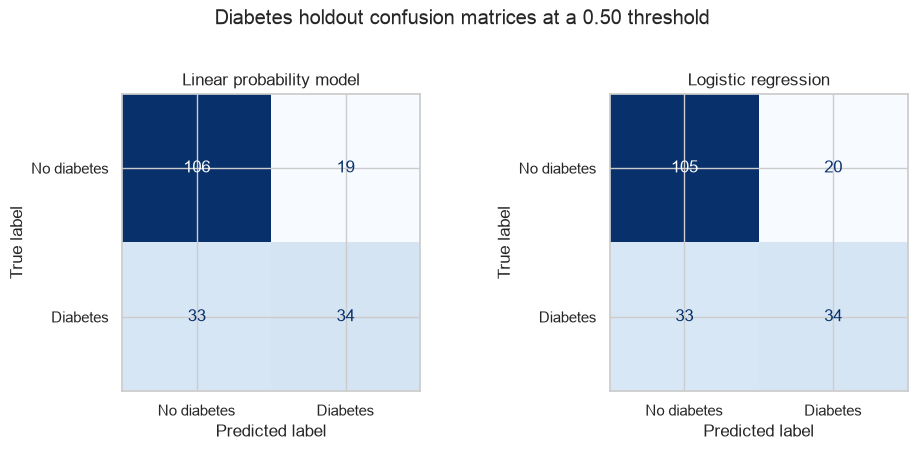

In [17]:
linear_probability_predictions = (linear_probability_scores >= 0.50).astype(int)
logistic_predictions = (logistic_probability_scores >= 0.50).astype(int)

figure, axes = plt.subplots(1, 2, figsize=(10, 4.4))
for axis, predictions, title in [
    (axes[0], linear_probability_predictions, "Linear probability model"),
    (axes[1], logistic_predictions, "Logistic regression"),
]:
    ConfusionMatrixDisplay.from_predictions(
        diabetes_y_test,
        predictions,
        display_labels=["No diabetes", "Diabetes"],
        cmap="Blues",
        colorbar=False,
        ax=axis,
    )
    axis.set_title(title)
figure.suptitle("Diabetes holdout confusion matrices at a 0.50 threshold", y=1.02)
plt.tight_layout()
plt.show()

On this single holdout, the two approaches have similar ranking and threshold metrics. That
does **not** make ordinary linear regression a valid probability model: 27 predictions fall
below zero or above one, and its error assumptions do not match a binary target. Logistic
regression respects probability bounds by construction. Neither result is suitable for
clinical use; the dataset is small, zero placeholders require assumptions, and no external
validation or calibration assessment is provided.

## Checks

In [18]:
assert len(iris_cls_X_train) + len(iris_cls_X_test) == len(iris)
assert len(iris_reg_X_train) + len(iris_reg_X_test) == len(iris)
assert len(diabetes_X_train) + len(diabetes_X_test) == len(diabetes)
assert set(iris_cls_X_train.index).isdisjoint(iris_cls_X_test.index)
assert set(iris_reg_X_train.index).isdisjoint(iris_reg_X_test.index)
assert set(diabetes_X_train.index).isdisjoint(diabetes_X_test.index)
assert selected_iris_regression_name == "All three measurements"
assert confusion_matrix(iris_cls_y_test, iris_class_predictions).sum() == 30
assert confusion_matrix(diabetes_y_test, logistic_predictions).sum() == 192
assert int(
    ((linear_probability_scores < 0) | (linear_probability_scores > 1)).sum()
) == 27
assert ((logistic_probability_scores >= 0) & (logistic_probability_scores <= 1)).all()
assert np.isfinite(diabetes_model_metrics.to_numpy()).all()
print("All schema, split, model-choice, metric, and probability-bound checks passed.")

All schema, split, model-choice, metric, and probability-bound checks passed.


## Takeaways

- Match the estimator to the target: linear regression for continuous outcomes, logistic
  regression for class probabilities.
- Use evaluation metrics that match the task. RMSE and R² answer regression questions;
  confusion matrices, F1, ROC-AUC, and average precision answer classification questions.
- A similar test score does not make an unsuitable model appropriate. Probability bounds and
  statistical assumptions still matter.
- Keep preprocessing inside the training pipeline and preserve an untouched holdout set.
- Treat unusually strong or weak results as evidence to investigate, not as proof of broad
  real-world performance.

### Possible extensions

- Add repeated cross-validation and hyperparameter tuning.
- Examine calibration and decision thresholds for the Diabetes classifier.
- Add regularised regression to stabilise correlated Iris coefficients.